## Agentic RAG

In [28]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [29]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import FAISS
from langchain_ollama import OllamaEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter


In [30]:
urls = {
    "https://docs.langchain.com/oss/python/langgraph/overview",
    "https://docs.langchain.com/oss/python/langgraph/workflows-agents",
    "https://docs.langchain.com/oss/python/langgraph/use-subgraphs"
}
docs = [WebBaseLoader(url).load() for url in urls]
docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceFault toleranceEvent streamingStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestBackward compatibilityLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendO

In [31]:
doc_list = [item for sublist in docs for item in sublist]
print(doc_list)
text_splitter = RecursiveCharacterTextSplitter(chunk_size= 1000, chunk_overlap= 100)
doc_splits = text_splitter.split_documents(doc_list)
print(doc_splits)

## Add all these text to vectordb

vectorstore = FAISS.from_documents(
    documents=doc_splits,
    embedding=OllamaEmbeddings(model="gemma:2b")
)

retriever = vectorstore.as_retriever()

[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/overview', 'title': 'LangGraph overview - Docs by LangChain', 'description': 'Gain control with LangGraph to design agents that reliably handle complex tasks', 'language': 'en'}, page_content='LangGraph overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangGraph overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartLocal serverChangelogThinking in LangGraphWorkflows + agentsCapabilitiesPersistenceFault toleranceEvent streamingStreamingInterruptsTime travelMemorySubgraphsProductionApplication structureTestBackward compatibilityLangSmith StudioAgent Chat UILangSmith DeploymentLangSmith ObservabilityFrontendOv

In [32]:
retriever.invoke("what is langgraph")

[Document(id='1143cf08-689d-48e0-a101-9074cc0c63da', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/use-subgraphs', 'title': 'Subgraphs - Docs by LangChain', 'language': 'en'}, page_content='Building multi-agent systems\nReusing a set of nodes in multiple graphs\nDistributing development: when you want different teams to work on different parts of the graph independently, you can define each part as a subgraph, and as long as the subgraph interface (the input and output schemas) is respected, the parent graph can be built without knowing any details of the subgraph\n\n\u200bSetup\npipuvpip install -U langgraph'),
 Document(id='697e0497-9d6e-4fbe-8122-4b013ce91d64', metadata={'source': 'https://docs.langchain.com/oss/python/langgraph/use-subgraphs', 'title': 'Subgraphs - Docs by LangChain', 'language': 'en'}, page_content='Subgraphs - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available page

In [33]:
### Retriever to Retriever Tools
from langchain_core.tools.retriever import create_retriever_tool
retriever_tool = create_retriever_tool(
    retriever,
    "retriever_vector_db_blog",
    "search and run information about Langgraph"
)


In [34]:
retriever_tool

StructuredTool(name='retriever_vector_db_blog', description='search and run information about Langgraph', args_schema=<class 'langchain_core.tools.retriever.RetrieverInput'>, func=<function create_retriever_tool.<locals>.func at 0x121102ac0>, coroutine=<function create_retriever_tool.<locals>.afunc at 0x120675440>)

### langchain Blogs -Separate vector  DB

In [35]:
langchain_urls = [
    "https://docs.langchain.com/oss/python/langchain/overview",
    "https://docs.langchain.com/oss/python/langchain/quickstart",
    "https://docs.langchain.com/oss/python/releases/changelog"
]

docs = [WebBaseLoader(url).load() for url in langchain_urls]
docs

[[Document(metadata={'source': 'https://docs.langchain.com/oss/python/langchain/overview', 'title': 'LangChain overview - Docs by LangChain', 'description': 'LangChain provides create_agent: a minimal, highly configurable agent harness. Compose exactly the agent your use case needs from model, tools, prompt, and middleware.', 'language': 'en'}, page_content='LangChain overview - Docs by LangChainDocumentation IndexFetch the complete documentation index at: /llms.txtUse this file to discover all available pages before exploring further.Skip to main contentDocs by LangChain home pageOpen sourceSearch...⌘KAsk AIGitHubTry LangSmithTry LangSmithSearch...NavigationLangChain overviewDeep AgentsLangChainLangGraphIntegrationsLearnReferenceContributePythonOverviewGet startedInstallQuickstartChangelogPhilosophyCore componentsAgentsModelsMessagesToolsShort-term memoryEvent streamingStreamingStructured outputMiddlewareOverviewPrebuilt middlewareCustom middlewareFrontendOverviewPatternsIntegrationsA

In [36]:
doc_list = [item for sublist in docs for item in sublist]
# print(doc_list)
text_splitter = RecursiveCharacterTextSplitter(chunk_size= 1000, chunk_overlap= 100)
doc_splits = text_splitter.split_documents(doc_list)
# print(doc_splits)

## Add all these text to vectordb

vectorstorelangchain = FAISS.from_documents(
    documents=doc_splits,
    embedding=OllamaEmbeddings(model="gemma:2b")
)

retrieverlangchain = vectorstorelangchain.as_retriever()

In [38]:
### Retriever to Retriever Tools
from langchain_core.tools.retriever import create_retriever_tool
retriever_tool_langchain = create_retriever_tool(
    retrieverlangchain,
    "retriever_vector_langchain_blog",
    "search and run information about Langchain"
)


In [39]:
tools = [retriever_tool, retriever_tool_langchain]

### Langgraph workflow

In [40]:
from typing import Annotated, Sequence
from typing_extensions import TypedDict

from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

class AgentState(TypedDict):
    # The add_messages function defines how an update should be processed
    # Default is to replace. add_messages says "append"
    messages: Annotated[Sequence[BaseMessage], add_messages]

In [41]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="qwen/qwen3-32b")
llm.invoke("Hi")

AIMessage(content='<think>\nOkay, the user just said "Hi". I need to respond appropriately. Since it\'s a greeting, I should reply with a friendly greeting as well. Let me make sure to keep it welcoming and offer assistance. Maybe something like "Hello! How can I assist you today?" That should cover it. I should also keep the tone positive and open. Let me check if there\'s anything else I need to add. No, that\'s good. Ready to send.\n</think>\n\nHello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 110, 'prompt_tokens': 9, 'total_tokens': 119, 'completion_time': 0.219678263, 'completion_tokens_details': None, 'prompt_time': 0.000692044, 'prompt_tokens_details': None, 'queue_time': 0.348196116, 'total_time': 0.220370307}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ea743-ee30-77f1-aee

In [42]:
def agent(state: AgentState):
    """
    Invoke the agent model to generate a response based on the current state. Given
    the question, it will decide to retrieve using the retriever tool, or simply end.

    Args:
        state (messages): The current state
    
    Returns:
        dict: The updated state with the agent response appended to message

    """
    print("---CALL AGENT---")
    messages = state["messages"]
    model = ChatGroq(model="qwen/qwen3-32b")
    model = model.bind_tools(tools)
    response = model.invoke(messages)
    # we return a list, because this will get added to the existing list
    return {"messages": [response]}

In [44]:
try:
    from langchain import hub
except Exception:
    # Fallback stub if langchain.hub isn't available in this env
    class _HubStub:
        def pull(self, name):
            from langchain_core.prompts import PromptTemplate
            return PromptTemplate(
                template="Use the following context to answer the question.\n\nContext:\n{context}\n\nQuestion:\n{question}\n\nAnswer:",
                input_variables=["context", "question"],
            )
    hub = _HubStub()
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import PromptTemplate
from langchain_groq import ChatGroq

from pydantic import BaseModel, Field


from typing import Annotated, Literal, Sequence
from typing_extensions import TypedDict


In [45]:
## Edges

def grade_documents(state) -> Literal["generate", "rewrite"]:
    """
    Determines whether the retrieved documents are relevant to the question.

    Args:
        state (messages): The current state
    
    Returns:
        str: A decision for whether the documents are relevent or not
    """

    print("---CHECK RELEVENCE---")

    # Data model
    class grade(BaseModel):
        """Binary score for relevance check"""

        binary_score: str = Field(description="Relevance score 'yes' or 'no'")

    # LLM
    model = ChatGroq(model="qwen/qwen3-32b") 

    # LLM with tool and validation
    llm_with_tool = model.with_structured_output(grade)

    # prompt
    prompt = PromptTemplate(
        template="""You are a grader assesssing the relevance of a retrieved document to a user question. \n
        Here is the retrieved document: \n\n {context} \n\n
        Here is the user question: {question} \n
        if the document contains keyword(s) or semantic meaning related to the user question, graded it as relevant. \n
        Give a binary score 'yes' or 'no' score to include whether the document is relevant to the question. """,
        input_variables=["context", "question"]
    )

    # chain
    chain = prompt | llm_with_tool

    messages = state["messages"]
    last_message = messages[-1]

    question = messages[0].content
    docs = last_message.content

    scored_result = chain.invoke({"question": question, "context": docs})

    score = scored_result.binary_score

    if score == "yes":
        print("---DECISION: DOCS RELEVANT---")
        return "generate"
    else:
        print("---DECISION: DOCS NOT RELEVANT---")
        print(score)
        return "rewrite"

In [46]:
def generate(state):
    """
    Generate answer

    Args:
        state (messages): The current state

    Returns:
         dict: The updated message
    """
    print("---GENERATE---")
    messages = state["messages"]
    question = messages[0].content
    last_message = messages[-1]

    docs = last_message.content

    #Prompt
    prompt = hub.pull("rim/rag-prompt")

    # LLM
    llm = ChatGroq(model="qwen/qwen3-32b")

    # Post-Processing 
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)
    
    # chain
    rag_chain = prompt | llm | StrOutputParser()

    # Run
    response = rag_chain.invoke({"context": docs, "question": question})
    return {"messages": [response]}

In [47]:
def rewrite(state):
    """
    Transform the query to produce a better question.

    Args:
        state (messages): The current state
    
    Returns:
        dict: The updated state with re-phrased question

    """
    print("---TRANSFORM QUERY---")
    messages = state["messages"]
    question = messages[0].content

    msg = [
        HumanMessage(
            content=f""" \n 
    Look at the input and try to reason about the underlying semantic intent / meaning. \n 
    Here is the initial question:
    \n ------- \n
    {question} 
    \n ------- \n
    Formulate an improved question: """,
        )
    ]

    # Grader
    model = ChatGroq(model="qwen/qwen3-32b")
    response = model.invoke(msg)
    return {"messages": [response]}

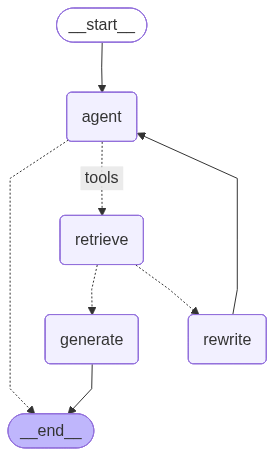

In [48]:
from langgraph.graph import END, StateGraph, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

# Define a new graph
workflow = StateGraph(AgentState)

# Define the nodes we will cycle between
workflow.add_node("agent", agent) # agent
retrieve = ToolNode([retriever_tool,retriever_tool_langchain])
workflow.add_node("retrieve", retrieve) # retrieval
workflow.add_node("rewrite", rewrite) # re-writing the question
workflow.add_node(
    "generate", generate
) # Generating a response after we know the documents are relevant
# call agent node to decide to retrieve or not
workflow.add_edge(START, "agent")

#Decide whether to retrieve
workflow.add_conditional_edges(
    "agent",
    # Assess agent decision
    tools_condition,
    {
        # Translate the condition outputs to nodes in our graph
        "tools": "retrieve",
        END: END,
    },
)
# Edges taken after the `action` node is called.
workflow.add_conditional_edges(
    "retrieve",
    # Assess agent decision
    grade_documents,
)
workflow.add_edge("generate", END)
workflow.add_edge("rewrite", "agent")

# Compile
graph = workflow.compile()
from IPython.display import Image, display
display(Image(graph.get_graph(xray=True).draw_mermaid_png()))
